In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mdsine2 as md2
from mdsine2.names import STRNAMES
import pickle
from sklearn import linear_model as lm
import h5py

[DEBUG] Using default logger (stdout, stderr).


In [2]:
npzfile = np.load("datasets/synthetic_5sp_rel_new/glv_5sp.npz")
npzfile

NpzFile 'datasets/synthetic_5sp_rel_new/glv_5sp.npz' with keys: growth_rates, interactions, initial_mean, initial_std

In [3]:
gr = npzfile["growth_rates"]
ints = npzfile["interactions"]

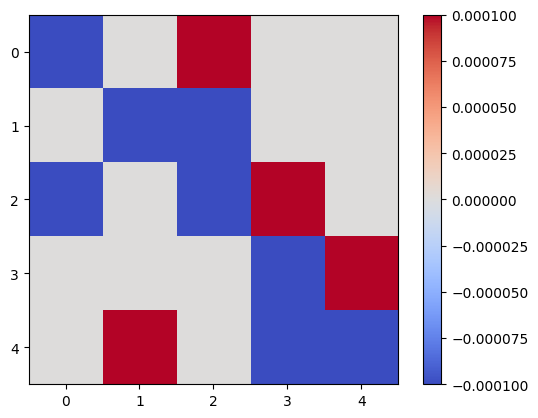

In [4]:
plt.imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
plt.colorbar()

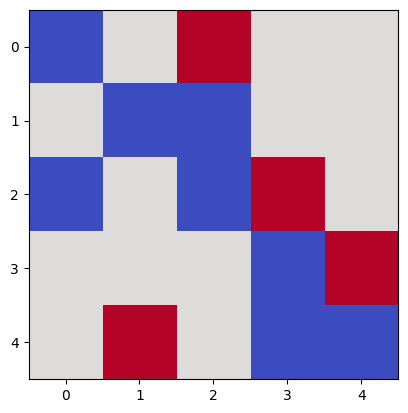

In [5]:
plt.imshow(np.sign(ints), cmap="coolwarm")

In [6]:
with open("datasets/synthetic_5sp_rel_new/output/reads_100000/cohort1/trial_0/low_noise/mdsine2/simulated-low/mcmc.pkl", "rb") as file:
    mcmc = pickle.load(file)

AttributeError: module '__main__' has no attribute 'FilteringWithoutQPCR'

In [8]:
gr_est = md2.summary(mcmc.graph[STRNAMES.GLV_PARAMETERS].growth)["mean"]

NameError: name 'mcmc' is not defined

In [8]:
gr_est

array([0.98308006, 0.88050143, 0.78913147, 0.91938344, 0.79582443])

In [9]:
md2.summary(mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE])["mean"]

array([5.74580642e-05, 6.17065326e-05, 7.89589233e-05, 6.79357760e-05,
       8.79657543e-05])

In [10]:
gr_est = md2.summary(mcmc.graph[STRNAMES.GROWTH_VALUE])["median"]

In [11]:
mcmc

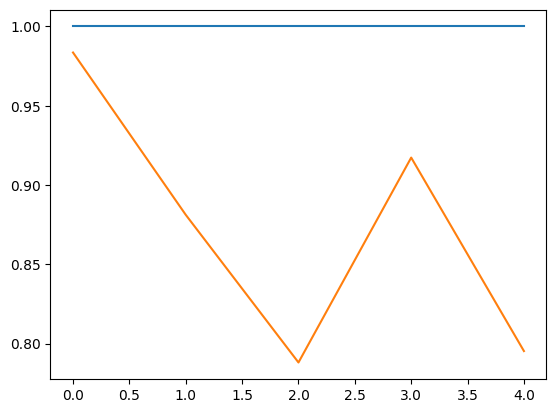

In [12]:
plt.plot(gr)
plt.plot(gr_est)

In [13]:
ints_est = md2.summary(mcmc.graph[STRNAMES.INTERACTIONS_OBJ].get_trace_from_disk())["mean"]-np.diag(md2.summary(mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk())["mean"])

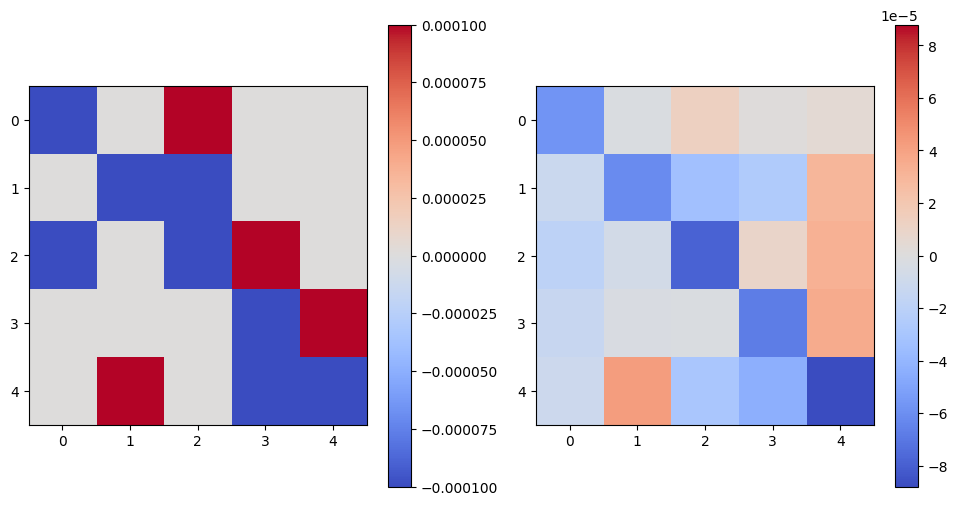

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est, cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

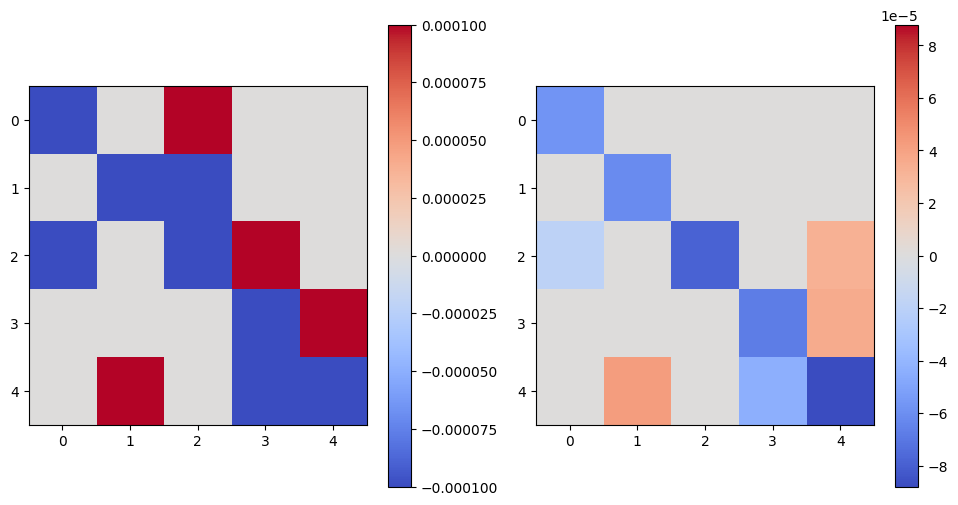

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est*(md2.generate_interation_bayes_factors_posthoc(mcmc, )>10)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

In [21]:
from scipy.stats import spearmanr, pearsonr

In [22]:
spearmanr(gr, gr_est)

SignificanceResult(statistic=nan, pvalue=nan)

In [23]:
mcmc.graph[STRNAMES.PROCESSVAR].get_trace_from_disk().mean()

np.float64(0.06985777031580041)

In [24]:
spearmanr((ints).flatten(), (ints_est).flatten())

SignificanceResult(statistic=np.float64(0.8839916156110237), pvalue=np.float64(4.67955493170181e-09))

In [25]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.7761922789107946), pvalue=np.float64(5.107944124117271e-06))

In [26]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

SignificanceResult(statistic=np.float64(0.5901445144582854), pvalue=np.float64(0.0019009359097517135))

In [27]:
spearmanr((ints).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)+np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.7847027923341), pvalue=np.float64(3.422321885072086e-06))

In [28]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

PearsonRResult(statistic=np.float64(0.7652419489743691), pvalue=np.float64(8.343740719738588e-06))

In [29]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

PearsonRResult(statistic=np.float64(0.5985666084771772), pvalue=np.float64(0.0015724111666006889))

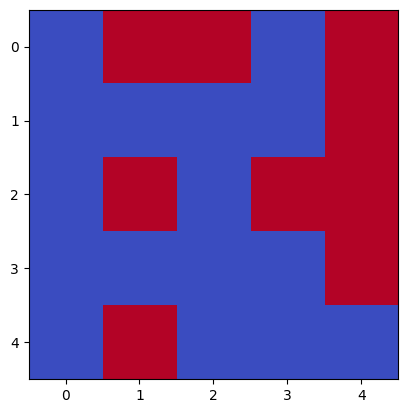

In [30]:
plt.imshow(np.sign(ints_est), cmap="coolwarm")

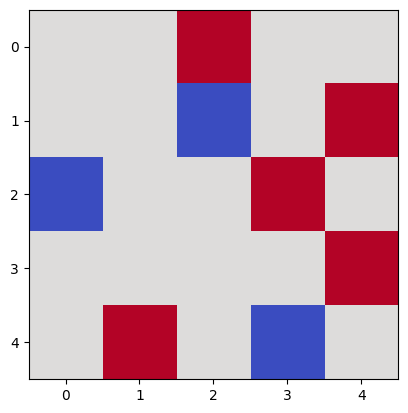

In [32]:
plt.imshow(np.sign(ints)+np.eye(5), cmap="coolwarm")

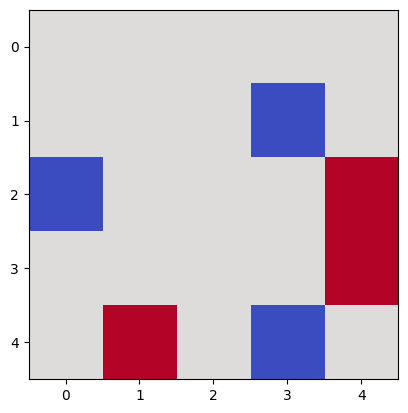

In [33]:
plt.imshow(np.sign(ints_est)*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10), cmap="coolwarm")

---

In [132]:
subjsets = []
cohorts = [1, 4, 7, 10]
trials = [0, 2, 4, 6]

traces = []

for cohort in cohorts:
    subjsets.append([])
    traces.append([])
    for trial in trials:
        with open(f"datasets/synthetic_5sp_rel_new/data/cohort{cohort}/trial_{trial}/reads_100000/noise_low/subjset.pkl", "rb") as file:
            subjsets[-1].append(pickle.load(file))

        traces[-1].append(h5py.File(f"datasets/synthetic_5sp_rel_new/output/reads_100000/cohort{cohort}/trial_{trial}/low_noise/mdsine2/simulated-low/traces.hdf5", "r"))

In [8]:
list(subjsets[1][0].qpcr.values())[0].data.mean()

np.float64(5795.910624925168)

In [27]:
t = subjsets[0][0].times

In [28]:
len(subjsets)

4

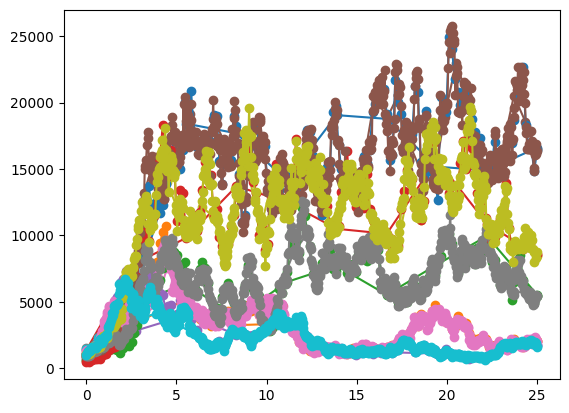

In [11]:
plt.plot(subjsets[0][0].times, subjsets[0][0].matrix()["abs"].T, "-o")
plt.plot(subjsets[1][0].times, subjsets[1][0].matrix()["abs"].T, "-o")
plt.plot(subjsets[2][0].times, subjsets[2][0].matrix()["abs"].T, "-o")
plt.plot(subjsets[3][0].times, subjsets[3][0].matrix()["abs"].T, "-o")
# plt.plot(X[:26]/25000, "--")

In [39]:
subjsets[0][5]

IndexError: list index out of range

In [19]:
subjsets[1][2]

IndexError: list index out of range

In [23]:
reads = np.array(list(subjsets[0][0].reads.values()))
qpcr = np.array([i.data.mean() for i in subjsets[0][0].qpcr.values()])

X = reads*qpcr.reshape((-1,1))

dX = np.diff(X, axis=0)
X = X[:-1]

# for i in range(5):
#     reads = np.array(list(subjsets[0][i].reads.values()))
#     qpcr = np.array([k.data.mean() for k in subjsets[0][i].qpcr.values()])

#     x = reads*qpcr.reshape((-1,1))
#     dx = np.diff(x, axis=0)

#     X = np.concatenate([X, x[:-1]], axis=0)
#     dX = np.concatenate([dX, dx], axis=0)

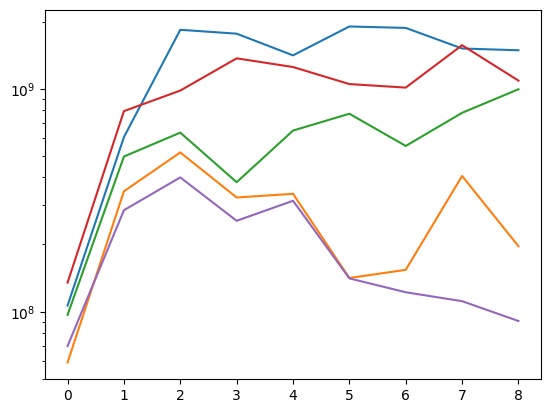

In [24]:
plt.plot(X)
plt.yscale("log")

In [25]:
reg = lm.LinearRegression(fit_intercept=False)

In [26]:
Aest = np.zeros((10,11))

for i in range(10):
    feats = np.hstack([X[i*26:(i+1)*26,[i]], X[i*26:(i+1)*26,[i]]*X[i*26:(i+1)*26]])
    reg.fit(feats, dX[i*26:(i+1)*26,i]/np.diff(t))
    Aest[i] = reg.coef_

NameError: name 't' is not defined

In [19]:
reg.coef_

AttributeError: 'LinearRegression' object has no attribute 'coef_'

NameError: name 'gr_est' is not defined

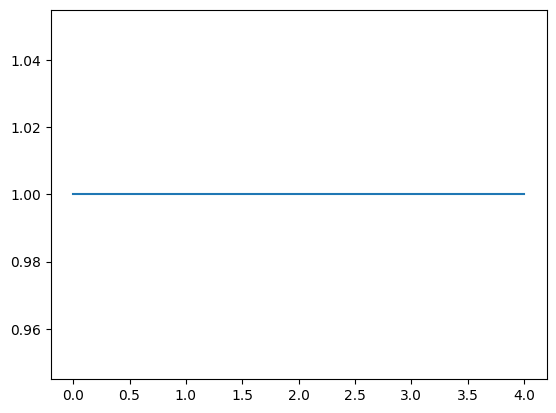

In [20]:
plt.plot(gr)
plt.plot(gr_est)
# plt.plot(Aest[:,0])

In [31]:
plt.imshow(Aest[:,1:], cmap="coolwarm", vmin=-np.max(np.abs(Aest[:,1:])), vmax=np.max(np.abs(Aest[:,1:])))
plt.colorbar()

NameError: name 'Aest' is not defined

In [32]:
spearmanr(ints.flatten(), Aest[:,1:].flatten())

NameError: name 'spearmanr' is not defined

In [30]:
traces = h5py.File("datasets/synthetic_5sp_rel_new/output/reads_100000/cohort1/trial_0/low_noise/mdsine2/simulated-low/traces.hdf5", "r")

In [33]:
t.shape

(10,)

In [43]:
subjsets[0][0].matrix()["abs"]

{'raw': array([[22789, 24001, 42065, 43132, 35626, 47506, 50468, 34604, 38588,
         48105],
        [12645, 13704, 11833,  7928,  8511,  3526,  4136,  9260,  5085,
          5954],
        [20700, 19630, 14525,  9285, 16365, 19270, 14891, 17795, 25786,
         16065],
        [28881, 31397, 22437, 33425, 31578, 26187, 27225, 35804, 28194,
         24678],
        [14985, 11268,  9140,  6230,  7920,  3511,  3280,  2537,  2347,
          5198]]),
 'rel': array([[0.22789, 0.24001, 0.42065, 0.43132, 0.35626, 0.47506, 0.50468,
         0.34604, 0.38588, 0.48105],
        [0.12645, 0.13704, 0.11833, 0.07928, 0.08511, 0.03526, 0.04136,
         0.0926 , 0.05085, 0.05954],
        [0.207  , 0.1963 , 0.14525, 0.09285, 0.16365, 0.1927 , 0.14891,
         0.17795, 0.25786, 0.16065],
        [0.28881, 0.31397, 0.22437, 0.33425, 0.31578, 0.26187, 0.27225,
         0.35804, 0.28194, 0.24678],
        [0.14985, 0.11268, 0.0914 , 0.0623 , 0.0792 , 0.03511, 0.0328 ,
         0.02537, 0.02347, 0.05

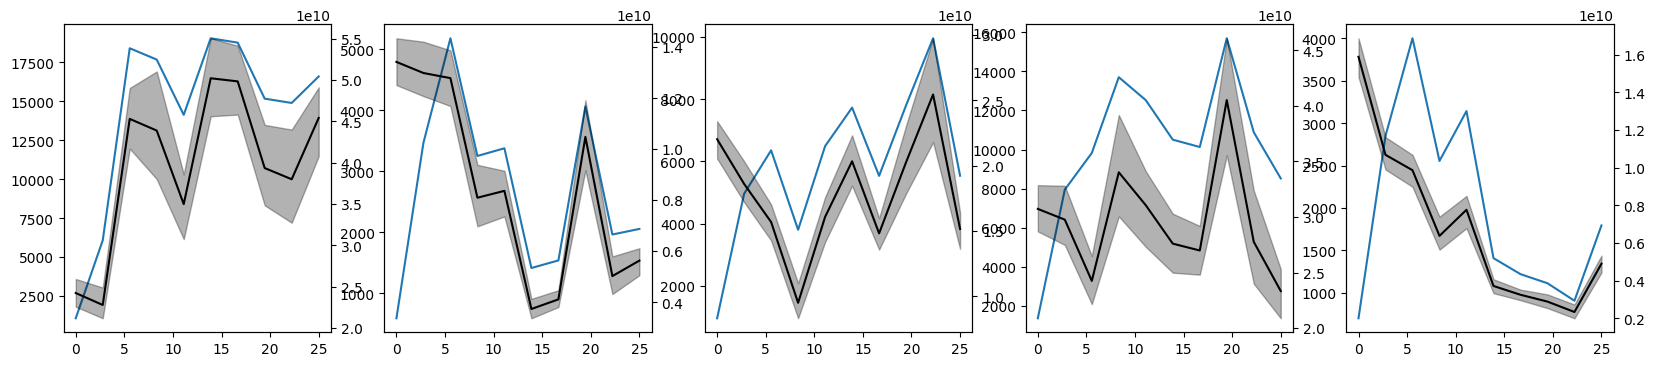

In [47]:
fig, ax = plt.subplots(1, 5, figsize=(20,4))

for i in range(5):
    ax.flatten()[i].plot(t, subjsets[0][0].matrix()["abs"].T[:,i])
    ax1 = ax.flatten()[i].twinx()
    ax1.plot(t, md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i], c="k")
    ax1.fill_between(t, *np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]), [5,95], axis=0)[:,i], color="k", alpha=0.3)

In [48]:
def generate_interation_bayes_factors_posthoc(traces):
    '''Generates the bayes factors on an item-item level for the interactions,
    given the passed in prior. All negative indicators are set as `np.nan`s in
    the trace, so we do `~np.isnan` to get the indicators.

    Since the prior is conjugate, we can fully integrate out the prior of the
    calculation:
        bf[i,j] = (count_on[i,j] * b) / (count_off[i,j] * a)

    Parameters
    ----------
    mcmc : mdsine2.BaseMCMC
        This is the inference object containing the traces
    section : str
        This is the section of the MH samples to take the samples

    Returns
    -------
    np.ndarray((n,n), dtype=float)
        These are the bayes factors for each of the interactions on an item-item level
    '''
    # interactions = mcmc.graph[STRNAMES.INTERACTIONS_OBJ]
    # trace = interactions.get_trace_from_disk(section=section)

    trace = traces[STRNAMES.INTERACTIONS_OBJ]
    
    trace = ~ np.isnan(trace)
    cnts_1 = np.sum(trace, axis=0)
    cnts_0 = np.sum(1-trace, axis=0)

    return cnts_1/cnts_0
    
    # print(cnts_1)
    # print()
    # print(cnts_0)

    # a = mcmc.graph[STRNAMES.CLUSTER_INTERACTION_INDICATOR_PROB].prior.a.value
    # b = mcmc.graph[STRNAMES.CLUSTER_INTERACTION_INDICATOR_PROB].prior.b.value

    # return (cnts_1 * b) / (cnts_0 * a)

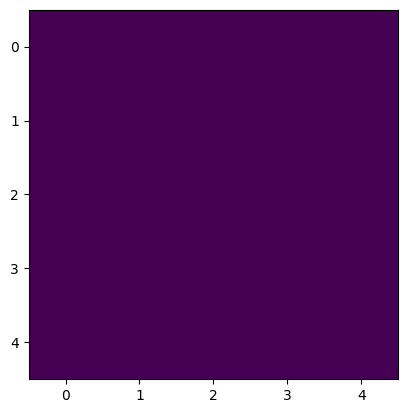

In [49]:
plt.imshow(generate_interation_bayes_factors_posthoc(traces)>10)

In [50]:
plt.imshow(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)

NameError: name 'mcmc' is not defined

---

In [50]:
import h5py

In [105]:
traces = h5py.File("datasets/synthetic_5sp_rel_new/output/reads_100000/cohort10/trial_2/low_noise/mdsine2/simulated-low/traces.hdf5", "r")

In [106]:
traces.keys()

<KeysViewHDF5 ['Cluster interaction indicator parameter', 'Cluster interaction probability', 'Growth parameter', 'Interactions object', 'Latent trajectory parameter_subj_0', 'Latent trajectory parameter_subj_1', 'Latent trajectory parameter_subj_2', 'Latent trajectory parameter_subj_3', 'Latent trajectory parameter_subj_4', 'Latent trajectory parameter_subj_5', 'Latent trajectory parameter_subj_6', 'Latent trajectory parameter_subj_7', 'Latent trajectory parameter_subj_8', 'Latent trajectory parameter_subj_9', 'Mean parameter for the normal prior of the interaction parameter', 'Mean parameter for the truncated normal prior of the growth parameter', 'Mean parameter for the truncated normal prior of the self-interaction parameter', 'Process Variance parameter', 'Self interaction parameter', 'Variance parameter for the normal prior of the interaction parameter']>

In [107]:
gr_est = md2.summary(np.array(traces[STRNAMES.GROWTH_VALUE]))["mean"]

In [108]:
ints_est = md2.summary(np.array(traces[STRNAMES.INTERACTIONS_OBJ]))["mean"]-np.diag(md2.summary(np.array(traces[STRNAMES.SELF_INTERACTION_VALUE]))["mean"])

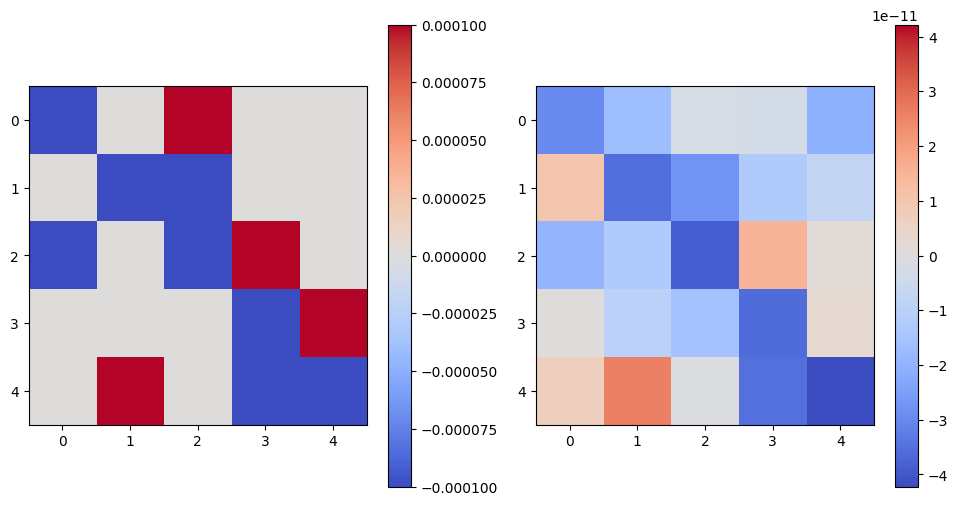

In [109]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est, cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

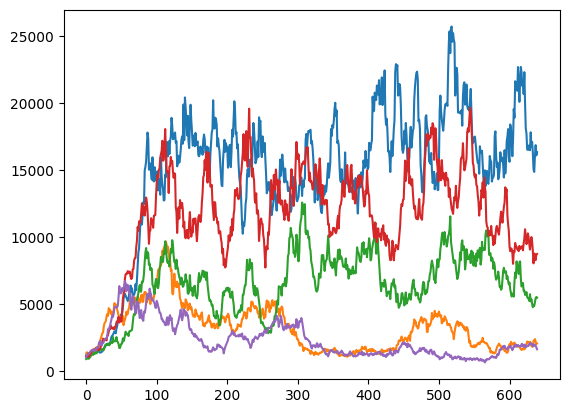

In [92]:
plt.plot(subjsets[-1][0].matrix()["abs"].T)

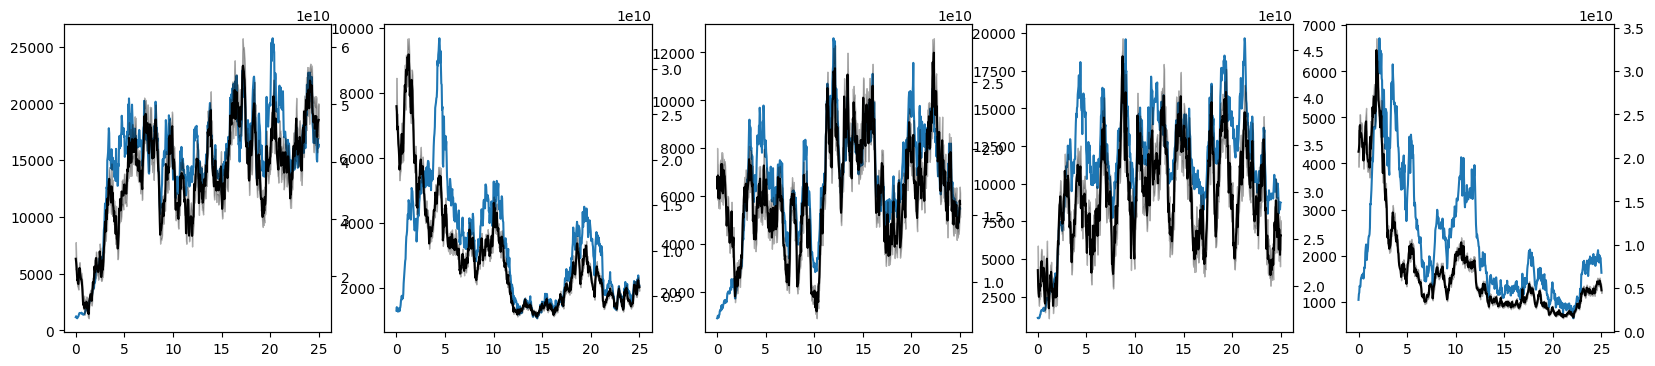

In [99]:
fig, ax = plt.subplots(1, 5, figsize=(20,4))

for i in range(5):
    ax.flatten()[i].plot(subjsets[-1][0].times, subjsets[-1][0].matrix()["abs"].T[:,i])
    ax1 = ax.flatten()[i].twinx()
    ax1.plot(subjsets[-1][0].times, md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i], c="k")
    ax1.fill_between(subjsets[-1][0].times, *np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]), [5,95], axis=0)[:,i], color="k", alpha=0.3)

In [125]:
shift

np.float64(2.910153929761471e-07)

In [159]:
np.array([md2.summary(np.array(traces[0][0][i]))["mean"].T for i in traces[0][0].keys() if STRNAMES.LATENT_TRAJECTORY in i]).shape

(4, 10, 5)

In [142]:
STRNAMES.LATENT_TRAJECTORY

'Latent trajectory parameter'

In [140]:
traces[0][0][STRNAMES.LATENT_TRAJECTORY+"_subj_0"]

<HDF5 dataset "Latent trajectory parameter_subj_0": shape (15000, 5, 10), type "<f8">

In [240]:
ms_list = []
A_list = []

for i, cohort in enumerate(cohorts):
    ms_list.append([])
    A_list.append([])
    for j, trial in enumerate(trials):
        ms_list[-1].append(np.array([md2.summary(np.array(traces[i][j][k]))["mean"].T for k in traces[i][j].keys() if STRNAMES.LATENT_TRAJECTORY in k]).shape)
        A_list[-1].append(get_A_bf(traces[i][j]))

In [233]:
cos_sim(ints.flatten(), A_list[i][j].flatten())

np.float64(0.6119824480712861)

In [242]:
np.array([[cos_sim(ints.flatten(), A_list[i][j].flatten()) for j in range(len(trials))] for i in range(len(trials))])

array([[0.61198245, 0.58809031, 0.66154105, 0.53429605],
       [0.62377265, 0.78705264, 0.65841226, 0.4023394 ],
       [0.61037528, 0.83392018, 0.59382059, 0.39798105],
       [0.64843111, 0.83064965, 0.59904111, 0.39665413]])

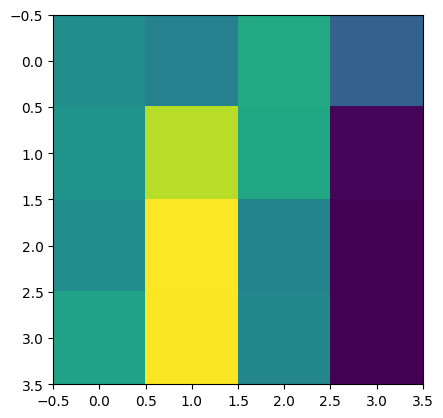

In [243]:
plt.imshow(np.array([[cos_sim(ints.flatten(), A_list[i][j].flatten()) for j in range(len(trials))] for i in range(len(trials))]))

In [131]:
len(traces)

20

In [134]:
md2.summary(np.array(traces[0][0][STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T.shape

(10, 5)

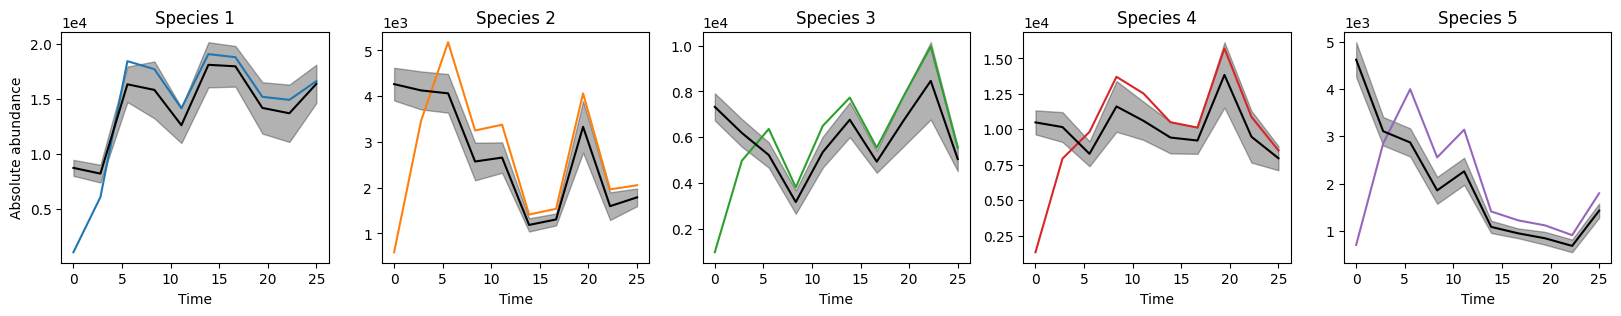

In [84]:
fig, ax = plt.subplots(1, 5, figsize=(20,3))
plt.subplots_adjust(hspace=0.5)

for i in range(5):
    ax[i].plot(subjsets[0][0].times, subjsets[0][0].matrix()["abs"][i], c=f"C{i}")
    shift = subjsets[0][0].matrix()["abs"][i].mean()/md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i].mean()
    ax[i].plot(subjsets[0][0].times, shift*md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i], c="k")
    # ax[i].fill_between(subjsets[0][0].times, *np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]), [2.275,97.725], axis=0)[:,i]*shift, color="k", alpha=0.3)
    ax[i].fill_between(subjsets[0][0].times, shift*(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i]-np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]).std(0)[i]*2), shift*(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i]+np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]).std(0)[i]*2), color="k", alpha=0.3)
    # ax[i].plot(subjsets[0][0].times, t_aug, shift*np.exp(ms_list[0][1:,i]), c="k")
    # ax[i].fill_between(t_aug, shift*np.exp(ms_list[0][1:,i]-Ps_list[0][1:,i,i]**0.5*2), shift*np.exp(ms_list[0][1:,i]+Ps_list[0][1:,i,i]**0.5*2), color="k", alpha=0.3)
    ax[i].ticklabel_format(axis="y", style="sci", scilimits=[0,0])
    ax[i].set_title(f"Species {i+1}")
    ax[i].set_xlabel("Time")
    if i==0:
        ax[i].set_ylabel("Absolute abundance")

# plt.savefig("estimate_abundance_mdsine.svg", format="svg", bbox_inches="tight")

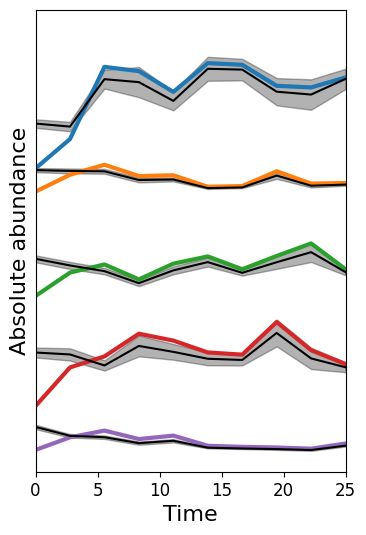

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(4,6))
plt.subplots_adjust(wspace=0.05)

for i in range(5):
    ax.plot(subjsets[0][0].times, -i*15000-subjsets[0][0].matrix()["abs"][i].mean()+subjsets[0][0].matrix()["abs"][i], c=f"C{i}", lw=3)
    shift = subjsets[0][0].matrix()["abs"][i].mean()/md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i].mean()
    ax.plot(subjsets[0][0].times, -i*15000-subjsets[0][0].matrix()["abs"][i].mean()+shift*md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i], c="k")
    # ax[i].fill_between(subjsets[0][0].times, *np.percentile(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]), [2.275,97.725], axis=0)[:,i]*shift, color="k", alpha=0.3)
    ax.fill_between(subjsets[0][0].times, -i*15000-subjsets[0][0].matrix()["abs"][i].mean()+shift*(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i]-np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]).std(0)[i]*2), -i*15000-subjsets[0][0].matrix()["abs"][i].mean()+shift*(md2.summary(np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]))["mean"].T[:,i]+np.array(traces[STRNAMES.LATENT_TRAJECTORY+f"_subj_{0}"]).std(0)[i]*2), color="k", alpha=0.3)
    ax.set_xlim(t[[0,-1]])
    ax.ticklabel_format(axis="y", style="sci", scilimits=[0,0])
    # ax.set_title(f"Species {i+1}", fontsize=18)
    ax.tick_params(axis="both", labelsize=12)
    ax.yaxis.get_offset_text().set_fontsize(12)
    ax.set_ylim(-65000, 1.4e4)
    if i==2:
        ax.set_xlabel("Time", fontsize=16)
    if i==0:
        ax.set_ylabel("Absolute abundance", fontsize=16)
    else:
        ax.set_yticks([])        

# plt.savefig("estimate_abundances_single_plot_mdsine.png", format="png", dpi=300, bbox_inches="tight")
# plt.savefig("estimate_abundances_single_plot_mdsine.svg", format="svg", bbox_inches="tight")

In [117]:
def cos_sim(a, b):
    return np.dot(a, b)/np.linalg.norm(a)/np.linalg.norm(b)

In [163]:
def get_A(traces):
    return md2.summary(np.array(traces[STRNAMES.INTERACTIONS_OBJ]))["mean"]-np.diag(md2.summary(np.array(traces[STRNAMES.SELF_INTERACTION_VALUE]))["mean"])

In [194]:
get_A(traces[0][0])*generate_interation_bayes_factors_posthoc(traces[0][0])>=10.

array([[False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False]])

In [214]:
def get_A_bf(traces, bf_threshold=10):
    A = get_A(traces)
    return A*(generate_interation_bayes_factors_posthoc(traces)>=10.)+np.diag(np.diag(A))

In [201]:
get_A(traces[0][0])*(generate_interation_bayes_factors_posthoc(traces[0][0])>=10.)

array([[-0., -0., -0.,  0., -0.],
       [-0., -0., -0., -0.,  0.],
       [-0., -0., -0.,  0., -0.],
       [-0., -0., -0., -0.,  0.],
       [ 0., -0., -0.,  0., -0.]])

In [174]:
get_A(traces[0][0])*(generate_interation_bayes_factors_posthoc(traces[0][0])>=10.)

array([[-0., -0., -0.,  0., -0.],
       [-0., -0., -0., -0.,  0.],
       [-0., -0., -0.,  0., -0.],
       [-0., -0., -0., -0.,  0.],
       [ 0., -0., -0.,  0., -0.]])

In [180]:
get_A(traces[0][0])

array([[-7.76150220e-12, -3.36030739e-13, -2.26387123e-14,
         1.75545312e-12, -4.85642263e-12],
       [-1.09616088e-12, -2.59225182e-11, -2.72856472e-12,
        -6.71525109e-12,  1.83183148e-11],
       [-2.19745700e-12, -9.54174022e-12, -2.11658718e-11,
         4.42705897e-12, -8.01475907e-12],
       [-9.67258434e-13, -1.42252002e-12, -1.50842256e-12,
        -1.60136233e-11,  2.35838762e-12],
       [ 0.00000000e+00, -2.77752816e-12, -2.68542198e-12,
         3.11275244e-13, -1.95122367e-11]])

In [198]:
get_A(traces[0][0])*(generate_interation_bayes_factors_posthoc(traces[0][0])>=10.)

array([[-0., -0., -0.,  0., -0.],
       [-0., -0., -0., -0.,  0.],
       [-0., -0., -0.,  0., -0.],
       [-0., -0., -0., -0.,  0.],
       [ 0., -0., -0.,  0., -0.]])

In [197]:
(generate_interation_bayes_factors_posthoc(traces[0][0])>=10.)

array([[False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False]])

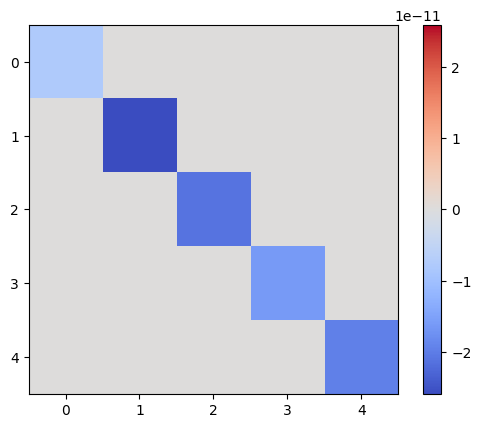

In [195]:
# plt.imshow(p_est2[5:30].reshape((5,5)), cmap="coolwarm", vmin=-np.max(np.abs(p_est2[5:30])), vmax=np.max(np.abs(p_est2[5:30])))
plt.imshow(get_A(traces[0][0])*(generate_interation_bayes_factors_posthoc(traces[0][0])>=10.)+np.diag(np.diag(get_A(traces[0][0]))), cmap="coolwarm", vmin=-np.max(np.abs(get_A(traces[0][0]))), vmax=np.max(np.abs(get_A(traces[0][0]))))
# plt.imshow(get_A(traces[0][0]), cmap="coolwarm", vmin=-np.max(np.abs(get_A(traces[0][0]))), vmax=np.max(np.abs(get_A(traces[0][0]))))
# plt.imshow(ints_est*(generate_interation_bayes_factors_posthoc(traces[0][0])>=10.)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))

plt.colorbar()
# plt.savefig("estimated_interactions_mdsine.svg", format="svg", bbox_inches="tight")

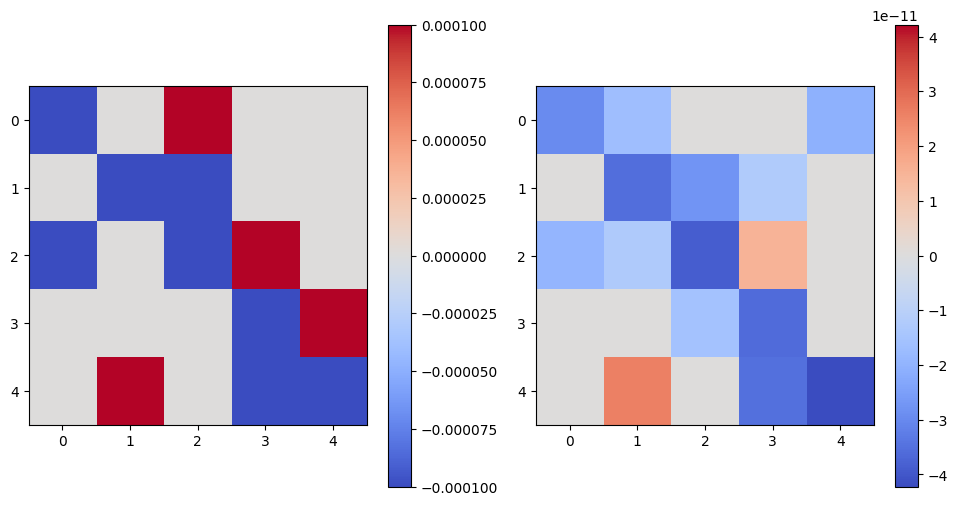

In [113]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

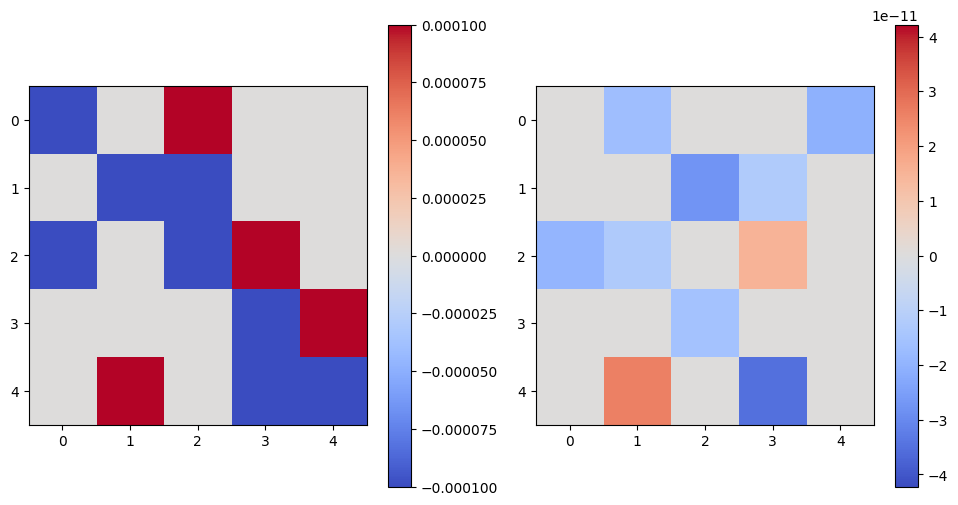

In [114]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

In [83]:
(ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.)+np.diag(np.diag(ints_est))).flatten()

array([-2.01967673e-11,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.45969307e-11,  0.00000000e+00, -3.60681611e-11, -2.34127044e-11,
        0.00000000e+00,  0.00000000e+00, -1.16626432e-11,  0.00000000e+00,
       -3.82439878e-11,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -2.93874865e-11,  0.00000000e+00,
        0.00000000e+00,  2.43637292e-11,  0.00000000e+00, -2.78260958e-11,
       -4.44108495e-11])

In [82]:
cos_sim(ints.flatten(), (ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.)+np.diag(np.diag(ints_est))).flatten())

np.float64(0.6119824480712861)

In [88]:
ints-np.diag(np.diag(ints))

array([[ 0.    ,  0.    ,  0.0001,  0.    ,  0.    ],
       [ 0.    ,  0.    , -0.0001,  0.    ,  0.    ],
       [-0.0001,  0.    ,  0.    ,  0.0001,  0.    ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.0001],
       [ 0.    ,  0.0001,  0.    , -0.0001,  0.    ]])

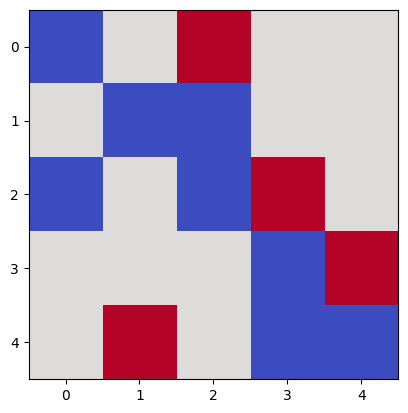

In [124]:
plt.imshow(ints, cmap="coolwarm")

In [83]:
cos_sim((ints-np.diag(np.diag(ints))).flatten(), (ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.)).flatten())

np.float64(nan)

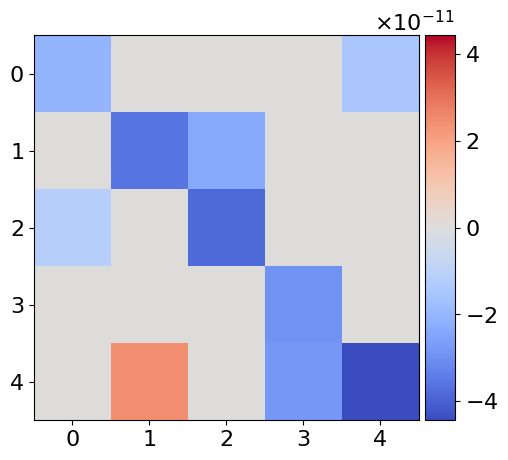

In [53]:
def add_colorbar(im, width=None, pad=None, **kwargs):

    l, b, w, h = im.axes.get_position().bounds       # get boundaries
    width = width or 0.1 * w                         # get width of the colorbar
    pad = pad or width                               # get pad between im and cbar
    fig = im.axes.figure                             # get figure of image
    cax = fig.add_axes([l + w + pad, b, width, h])   # define cbar Axes
    return fig.colorbar(im, cax=cax, **kwargs)       # draw cbar

from matplotlib import ticker

cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((0,0))
cbformat.set_useMathText(True)

fig, ax = plt.subplots(1, 1, figsize=(6,5))

# im = ax.imshow(p_est2[5:30].reshape((5,5)), cmap="coolwarm", vmin=-np.max(np.abs(p_est2[5:30])), vmax=np.max(np.abs(p_est2[5:30])))
im = ax.imshow(ints_est*(generate_interation_bayes_factors_posthoc(traces)>=10.)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))

ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

cbar = add_colorbar(im, 5e-2, 1e-2, format=cbformat)
# cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontsize=16)
# cbar.ax.tick_params(labelsize=16)
# cbar.ax.set_yticks(cbar.ax.get_yticks())#, fontsize=16)
cbar.ax.tick_params(labelsize=16)
cbar.ax.yaxis.offsetText.set(size=16)

plt.savefig("estimated_interactions_mdsine.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig("estimated_interactions_mdsine.svg", format="svg", bbox_inches="tight")
plt.show()

In [20]:
from scipy.stats import spearmanr, pearsonr

In [21]:
spearmanr(gr, gr_est)

SignificanceResult(statistic=np.float64(-0.1515151515151515), pvalue=np.float64(0.6760651759978539))

In [128]:
mcmc.graph[STRNAMES.PROCESSVAR].get_trace_from_disk().mean()

np.float64(0.19012891907758775)

In [36]:
spearmanr((ints).flatten(), (ints_est).flatten())

SignificanceResult(statistic=np.float64(0.66712359197748), pvalue=np.float64(3.4998005438560444e-14))

In [37]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.5535974798769446), pvalue=np.float64(2.3167629557750118e-09))

In [57]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

SignificanceResult(statistic=np.float64(0.747881320660978), pvalue=np.float64(3.888298164136079e-19))

In [58]:
spearmanr((ints).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)+np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.8226865066386722), pvalue=np.float64(8.93653331197679e-26))

In [59]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

PearsonRResult(statistic=np.float64(0.7400269014111068), pvalue=np.float64(1.4164075709595746e-18))

In [60]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

PearsonRResult(statistic=np.float64(0.7883897417554289), pvalue=np.float64(2.1272455995785715e-22))

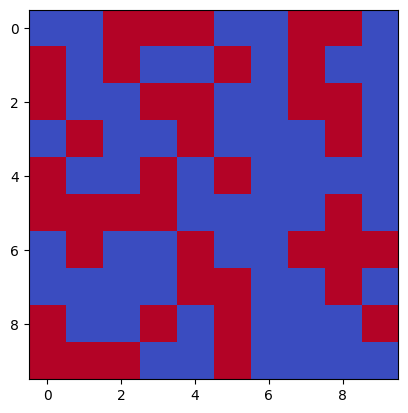

In [61]:
plt.imshow(np.sign(ints_est), cmap="coolwarm")

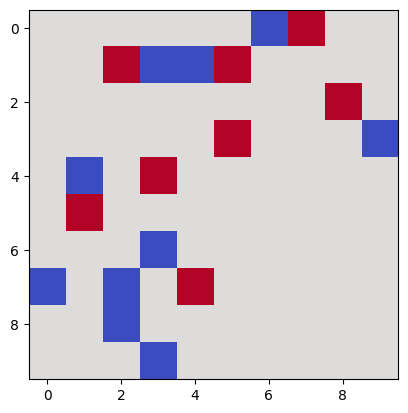

In [93]:
plt.imshow(np.sign(ints)+np.eye(10), cmap="coolwarm")

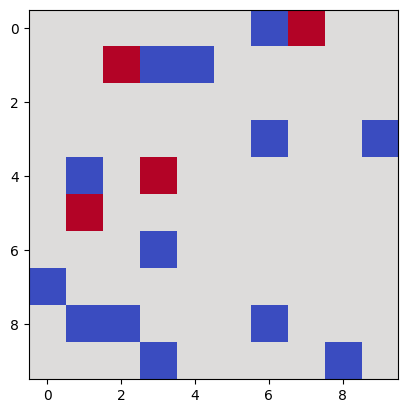

In [74]:
plt.imshow(np.sign(ints_est)*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10), cmap="coolwarm")